# 03 — Baselines: *How far do shallow features get you?*

Before the full engine model, we fix the **reference points** every later number is measured
against, and look at how the baseline errs:

| reference | what it predicts | role |
|---|---|---|
| **predict-mean** | the training-mean rating, for everyone | the trivial floor — any model must beat it |
| **copy-opponent** | the *opponent's* rating | the **leak** — what a model could reach by peeking at matchmaking |
| **ridge / LightGBM (no engine)** | rating from game shape, opening and own result | honest but shallow — how much do surface features carry? |

All four are fit and scored on the **same grouped hold-out split** (20% of players held out;
no player appears in both train and test). Two questions:

1. **How much does matchmaking reveal?** Copy-opponent is far better than any legitimate model,
   because Lichess pairs similar ratings — which is exactly why opponent information is banned.
2. **How far do features get you *without* engine evaluations?** Game length, captures, checks,
   opening code, time control and the player's own result.

In [1]:
# --- Setup: paths, style, and the shared save-and-show helper -------------------------------
import sys, json, warnings
from pathlib import Path

# Make `import src...` work whether the notebook is run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import load_config
from src.plotting import set_style, save_fig
from src.model import (
    add_opponent_rating, evaluate, grouped_split, make_lgbm,
    BASELINE_FEATURES, BASELINE_CAT, mae,
)

warnings.filterwarnings("ignore")          # keep library chatter out of the rendered notebook
cfg = load_config()
set_style()                                 # one house style for every figure
OUT = cfg["outputs"]                        # every data/report path comes from config.yaml
FIGROOT = Path(cfg["paths"]["figures"])
FIG = FIGROOT / "notebook_03_baseline"                  # this notebook's figure folder (auto-created)
BANDS = cfg["rating_bands"]

def show(path):
    "Display a figure that save_fig() just wrote to reports/figures/."
    display(Image(filename=str(path)))

# Attach opponent_rating (for the copy-opponent reference ONLY — never a model feature).
feats = pd.read_parquet(OUT["features"])
games = pd.read_parquet(OUT["games_clean"], columns=["game_id", "white_elo", "black_elo"])
df = add_opponent_rating(feats, games)
A = json.loads(Path(OUT["eval_artifacts"]).read_text(encoding="utf-8"))   # full-model results (nb04)
print("instances:", f"{len(df):,}", "| baseline features:", BASELINE_FEATURES)

instances: 606,578 | baseline features: ['game_plies', 'player_moves', 'n_captures', 'n_checks', 'result', 'time_control', 'eco']


## 1. The baseline feature set

`BASELINE_FEATURES` excludes **all** engine (centipawn / accuracy) and **all** clock features —
those are held back for the improved model so the comparison is clean. What remains is surface
information available without any engine analysis:

- **shape:** `game_plies`, `player_moves`, `n_captures`, `n_checks`
- **opening:** `eco` (opening code)
- **own result and time control:** `result`, `time_control`

In [2]:
print(f"distinct eco codes: {df['eco'].nunique()},  distinct time controls: {df['time_control'].nunique()}")

# Stage 5 in one call: predict-mean, copy-opponent, ridge and LightGBM on the SAME grouped split.
# (~1-2 minutes: fits a ridge and a LightGBM on ~486k training rows.)
results = evaluate(df, cfg)

order = ["predict_mean", "copy_opponent", "ridge", "lightgbm"]
table = pd.DataFrame(
    [(k, round(results[k]["mae"], 1), round(results[k]["rmse"], 1)) for k in order],
    columns=["model", "MAE", "RMSE"],
).set_index("model")
print(f"grouped hold-out: n_train={int(results['_meta']['n_train']):,}  n_test={int(results['_meta']['n_test']):,}")
display(table)
lgb_mae, opp_mae = results["lightgbm"]["mae"], results["copy_opponent"]["mae"]
print(f"LightGBM (no engine) vs predict-mean: {1 - lgb_mae / results['predict_mean']['mae']:.1%} lower MAE")
print(f"copy-opponent MAE is {lgb_mae / opp_mae:.1f}x lower than LightGBM (no engine) "
      f"and {A['full_mae'] / opp_mae:.1f}x lower than the full engine model ({A['full_mae']:.1f}, nb04)")

distinct eco codes: 484,  distinct time controls: 66


grouped hold-out: n_train=486,065  n_test=120,513


,MAE,RMSE
model,,
predict_mean,364.8,445.1
copy_opponent,80.9,152.0
ridge,297.9,369.4
lightgbm,292.5,365.6


LightGBM (no engine) vs predict-mean: 19.8% lower MAE
copy-opponent MAE is 3.6x lower than LightGBM (no engine) and 3.0x lower than the full engine model (239.1, nb04)


**Reading the table.**

- **predict-mean ≈ 365.** Guess the average rating for everyone and you miss by about 365 on
  average. Any useful model lives below this line.
- **copy-opponent ≈ 81.** Far better than every legitimate model — about 3.6× lower MAE than the
  no-engine LightGBM and about 3× lower than the full engine model — and unusable: it works only
  because the opponent's rating is a near-copy of yours (notebook 01, §8). This number is the
  empirical case for the leakage guard.
- **ridge ≈ 298, LightGBM ≈ 293.** The honest shallow models cut the error by about 20% relative to
  predict-mean. LightGBM edges ridge by using non-linear interactions among the surface features.

(The Stage-5 LightGBM here trains a fixed 3,000 trees on the whole training split. Notebook 04's
"no-engine baseline" row is the same feature set trained with early stopping on a validation split
carved from training, which gives 293.4; the two agree to within 1 Elo.)

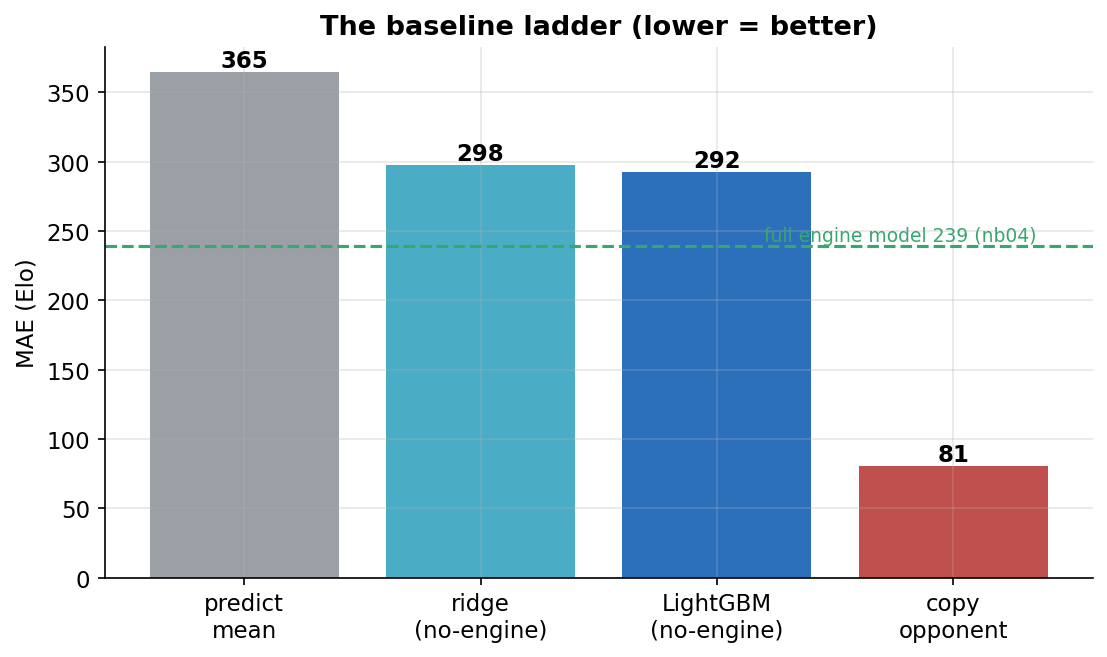

In [3]:
# The ladder, with the full engine model (notebook 04, reports/eval_artifacts.json) as a target line.
FULL_MODEL_MAE = A["full_mae"]
names = ["predict\nmean", "ridge\n(no-engine)", "LightGBM\n(no-engine)", "copy\nopponent"]
vals = [results["predict_mean"]["mae"], results["ridge"]["mae"], results["lightgbm"]["mae"], opp_mae]
colors = ["#9aa0a6", "#4bacc6", "#2c6fbb", "#c0504d"]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.bar(names, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
ax.axhline(FULL_MODEL_MAE, color="#3aa66f", ls="--", lw=1.5)
ax.text(3.35, FULL_MODEL_MAE + 4, f"full engine model {FULL_MODEL_MAE:.0f} (nb04)",
        color="#3aa66f", ha="right", fontsize=9)
ax.set(ylabel="MAE (Elo)", title="The baseline ladder (lower = better)")
show(save_fig(fig, "baseline_ladder", FIG))

**The copy-opponent lesson.** The best single predictor of your rating in this data is *who
Lichess paired you against*, not how you played. A model allowed to see the opponent would score
about 81 and learn little about chess. By excluding opponent-derived features and splitting by
`username`, the model has to earn its accuracy from the player's own moves and clock. From here on
the honest reference is the ~293 shallow baseline, not the ~81 leak.

## 2. Error analysis of the shallow model

Metrics summarise; plots diagnose. We refit the no-engine LightGBM on the **same** grouped split
(deterministic seed, so the test set matches the table) to look at *how* it errs.

In [4]:
d = df.copy()
for col in BASELINE_CAT:                      # stabilise category codes across the split (as evaluate does)
    d[col] = d[col].astype("category")
train, test = grouped_split(d, cfg["model"]["test_size"], cfg["random_seed"])
y_tr = train["rating"].to_numpy(float)
y_te = test["rating"].to_numpy(float)

lgbm = make_lgbm(cfg).fit(train[BASELINE_FEATURES], y_tr)
pred = lgbm.predict(test[BASELINE_FEATURES])
print(f"refit LightGBM baseline: MAE {mae(y_te, pred):.1f} (matches the table)   bias {np.mean(pred - y_te):+.1f}")
q = np.percentile(pred, [5, 50, 95]); qt = np.percentile(y_te, [5, 50, 95])
print(f"predictions 5/50/95%: {q.round(0)}   vs actual ratings 5/50/95%: {qt.round(0)}")

refit LightGBM baseline: MAE 292.5 (matches the table)   bias +2.7
predictions 5/50/95%: [1247. 1623. 2140.]   vs actual ratings 5/50/95%: [ 927. 1641. 2390.]


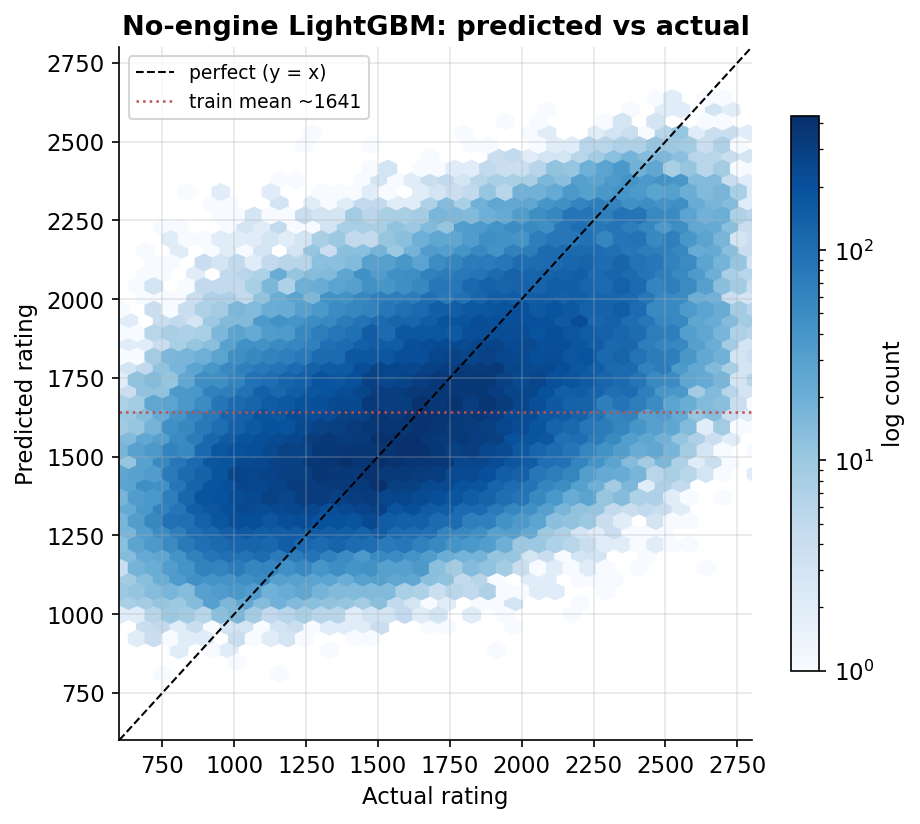

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 6))
hb = ax.hexbin(y_te, pred, gridsize=45, cmap="Blues", mincnt=1, bins="log")
lims = [600, 2800]
ax.plot(lims, lims, "k--", lw=1, label="perfect (y = x)")
ax.axhline(y_tr.mean(), color="#c0504d", ls=":", lw=1.2, label=f"train mean ~{y_tr.mean():.0f}")
ax.set(xlim=lims, ylim=lims, xlabel="Actual rating", ylabel="Predicted rating",
       title="No-engine LightGBM: predicted vs actual")
ax.legend(loc="upper left", fontsize=9)
fig.colorbar(hb, ax=ax, shrink=0.8, label="log count")
show(save_fig(fig, "baseline_pred_vs_actual", FIG))

**Reading the scatter.** The cloud is much flatter than the `y = x` diagonal: the 5–95% range of
the predictions (printed above) is far narrower than that of the actual ratings. With no
move-quality signal, the loss-minimising bet is to stay near the centre, so a true-1000 player is
pulled up and a true-2400 player is pulled down. This shrinkage is the *rational* response to weak
features, and the same mechanism (much milder) produces the tail bias of the full model.

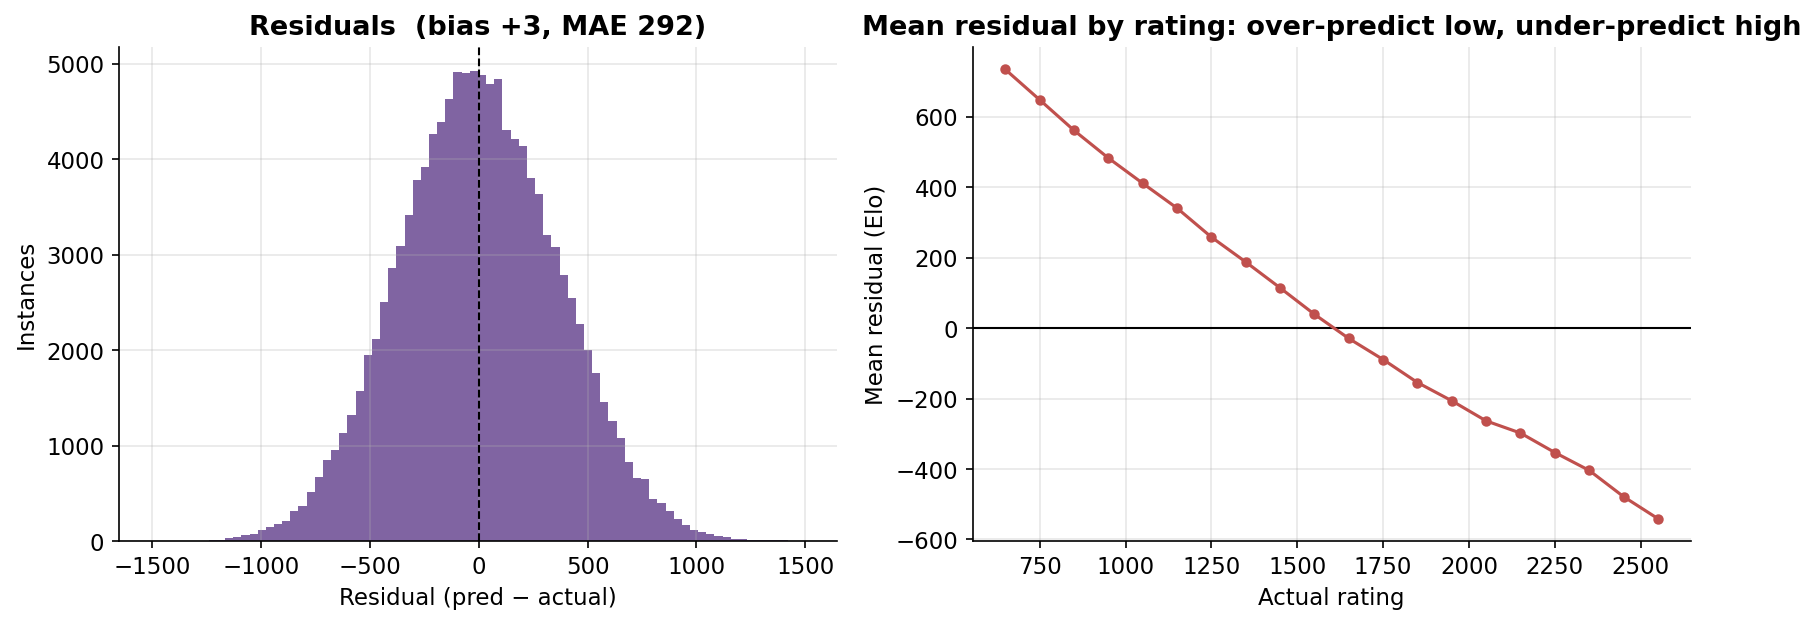

mean residual at 650: +734   at 2550: -541


In [6]:
resid = pred - y_te                                   # + = over-predicted
edges = np.arange(600, 2700, 100)
idx = np.digitize(y_te, edges)
cen, mres = [], []
for b in range(1, len(edges)):
    m = idx == b
    if m.sum() >= 200:
        cen.append((edges[b - 1] + edges[b]) / 2); mres.append(resid[m].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax1.hist(resid, bins=80, color="#8064a2")
ax1.axvline(0, color="k", ls="--", lw=1)
ax1.set(xlabel="Residual (pred − actual)", ylabel="Instances",
        title=f"Residuals  (bias {resid.mean():+.0f}, MAE {np.mean(np.abs(resid)):.0f})")
ax2.axhline(0, color="k", lw=1)
ax2.plot(cen, mres, "-o", color="#c0504d", ms=4)
ax2.set(xlabel="Actual rating", ylabel="Mean residual (Elo)",
        title="Mean residual by rating: over-predict low, under-predict high")
fig.tight_layout()
show(save_fig(fig, "baseline_residuals", FIG))
print(f"mean residual at {cen[0]:.0f}: {mres[0]:+.0f}   at {cen[-1]:.0f}: {mres[-1]:+.0f}")

**Reading the residuals.** The residual histogram is roughly centred (small global bias), but the
conditional view on the right is the real story: the shallow model **over-predicts low-rated players
by hundreds of Elo and under-predicts high-rated players by hundreds** — regression to the mean.
Notebook 05 studies the same pattern for the full model, where it is smaller but still present.
Seeing it already in the baseline is consistent with it coming from *weak evidence* rather than
from a particular feature set.

## Takeaways

- **The floor is ~365; the leak is ~81.** Honest shallow models reach ~293 (LightGBM) / ~298 (ridge)
  — about 20% better than predicting the mean.
- **Copy-opponent is the argument for the leakage guard**, not a candidate model.
- **Weak features → strong shrinkage** toward the mean: over-predicting the low end and
  under-predicting the high end.
- **The gap from ~293 to ~239 is what the full feature set (move quality, clock, game structure)
  buys** — notebook 04.